# Day-Ahead Desert-PV Forecasting with Explicit Aerosol Features: Ibri, Oman

**Research question.** Do explicit dust and aerosol features (AOD, PM2.5, PM10) improve
day-ahead PV forecasts at a desert site in Oman, beyond what irradiance already captures?

**What this notebook does, top to bottom:**
1. Assembles an open-data hourly dataset for Ibri, Oman (2022-2024) from three sources:
   NASA POWER (irradiance + weather, no API key), CAMS EAC4 reanalysis (AOD550, PM2.5, PM10,
   free Copernicus ADS account), and pvlib (physics model that converts irradiance into the
   modeled PV output target).
2. Engineers leakage-safe day-ahead features and builds two feature sets: with and without aerosols.
3. Trains five model variants: smart persistence, CatBoost (+/- aerosols), stacked GRU (+/- aerosols).
4. Evaluates RMSE, MAE, R2, and skill over persistence on a chronological held-out test set,
   overall and on high-dust vs low-dust subsets, with a day-block bootstrap CI on RMSE.
5. Attributes the CatBoost-with-aerosols model with SHAP (TreeExplainer).
6. Exports all paper figures at 300 DPI and prints a labelled results summary block whose
   labels match the `[[...]]` blanks in the companion paper.

**Day-ahead framing (important).** The forecast issued at 00:00 UTC covers the full
next-day hourly profile (24 values). EVERY input is information available at issue time:
all features are lags of 24 h or more (yesterday's PV, weather, and aerosols) plus
deterministic calendar encodings. No same-day reanalysis values are used. This matters
because the target is computed by pvlib from same-hour irradiance: feeding the models
that same-hour irradiance would make the task circular (they would simply re-learn the
physics formula and score a meaningless R2 of ~1.0). With lagged inputs only, the task
is a genuine forecast and the aerosol ablation is informative: dust events persist
across days, so yesterday's aerosol state can carry real next-day signal.

**Evaluation note.** Metrics are computed on daytime test hours only (GHI > 10 W/m2);
including night hours, where every model trivially predicts zero, inflates R2.

---
### Getting the CAMS (Copernicus ADS) credential
1. Register (free) at https://ads.atmosphere.copernicus.eu
2. Log in, open your profile page, and copy your **Personal Access Token**.
3. Accept the licence of the dataset "CAMS global reanalysis (EAC4)" once on its download page.
4. On Kaggle: Add-ons -> Secrets -> add a secret named `ADS_API_KEY` with the token as value.
   (Locally: set the `ADS_API_KEY` environment variable, or edit the clearly marked variable below.)

The NASA POWER API needs no key. Downloads are cached to disk, so re-runs are fast.

In [6]:
# ------------------------------------------------------------------
# 0. Environment: pinned versions, imports, seeds
# ------------------------------------------------------------------
# Install the extra libraries. Lower-bound constraints (not hard pins) so pip keeps
# Kaggle's preinstalled numpy 2.x / tensorflow stack intact; the next cell prints the
# exact resolved versions, which is the reproducibility record for the paper.
%pip install -q "numpy>=2.0" "pvlib>=0.11.1" "catboost>=1.2.8" "shap>=0.47" "cdsapi>=0.7.4" "netcdf4>=1.7.2"

Note: you may need to restart the kernel to use updated packages.


In [7]:
import os, json, time, math, random, warnings, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

import pvlib, catboost, shap, sklearn
print("pvlib", pvlib.__version__, "| catboost", catboost.__version__,
      "| shap", shap.__version__, "| tf", tf.__version__, "| sklearn", sklearn.__version__)

pvlib 0.15.2 | catboost 1.2.10 | shap 0.51.0 | tf 2.20.0 | sklearn 1.6.1


### Figure typography
Figures are drawn at the LNCS text width (122 mm) and saved at 1:1, so no
scaling happens in Word and the lettering lands at the same size and face as
the body text. Re-run every figure cell below after this one.


In [8]:
# ------------------------------------------------------------------
# Figure typography: match the LNCS body text
# ------------------------------------------------------------------
import matplotlib as mpl
from matplotlib import font_manager

# LNCS text block is 122 mm wide. Draw at that width and insert at 100 %.
TEXT_W_IN = 122 / 25.4          # 4.80 in

# Times New Roman if the machine has it, otherwise the closest metric clone.
_installed = {f.name for f in font_manager.fontManager.ttflist}
SERIF = next((f for f in ["Times New Roman", "Nimbus Roman",
                          "Liberation Serif", "DejaVu Serif"]
              if f in _installed), "serif")
print("figure font:", SERIF)

mpl.rcParams.update({
    "font.family":       "serif",
    "font.serif":        [SERIF],
    "mathtext.fontset":  "stix",     # keeps W/m^2 in a serif face
    "font.size":         8.0,
    "axes.titlesize":    8.5,
    "axes.labelsize":    8.0,
    "xtick.labelsize":   7.0,
    "ytick.labelsize":   7.0,
    "legend.fontsize":   7.0,
    "axes.linewidth":    0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "savefig.dpi":       400,
    "figure.dpi":        140,
    "savefig.bbox":      "tight",
    "savefig.pad_inches": 0.02,
})


figure font: Liberation Serif


In [9]:
# ------------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------------
SITE_NAME = "Ibri, Oman (near Ibri Solar 500 MW)"
SITE_LAT  = 23.05      # degrees North
SITE_LON  = 56.42      # degrees East
START     = "2022-01-01"
END       = "2024-12-31"        # inclusive, UTC
TEST_START_DATE = "2024-07-01"  # chronological split boundary (test = last 6 months)

DUST_PCTL = 75          # AOD percentile (computed on TRAIN only) defining high-dust hours
FIG_DPI   = 300
DATA_DIR  = pathlib.Path("data");    DATA_DIR.mkdir(exist_ok=True)
FIG_DIR   = pathlib.Path("figures"); FIG_DIR.mkdir(exist_ok=True)

# PV system modeled with pvlib (PVWatts chain): 1 MW-DC fixed-tilt utility block
PV_DC_KW   = 1000.0
PV_GAMMA   = -0.004     # power temperature coefficient [1/C]
PV_TILT    = 23.0       # ~ latitude
PV_AZIMUTH = 180.0      # south-facing
INV_AC_KW  = 850.0      # DC/AC ratio ~1.18

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": FIG_DPI,
                     "font.size": 9, "axes.grid": True, "grid.alpha": 0.3})

## 2. Data assembly
### 2.1 NASA POWER: hourly irradiance and weather (no API key)

In [10]:
POWER_PARAMS = ["ALLSKY_SFC_SW_DWN",   # GHI  [W/m2]
                "ALLSKY_SFC_SW_DNI",   # DNI  [W/m2]
                "ALLSKY_SFC_SW_DIFF",  # DHI  [W/m2]
                "T2M", "WS10M", "RH2M", "PS"]

def fetch_power_year(year):
    url = ("https://power.larc.nasa.gov/api/temporal/hourly/point"
           f"?parameters={','.join(POWER_PARAMS)}"
           f"&community=RE&longitude={SITE_LON}&latitude={SITE_LAT}"
           f"&start={year}0101&end={year}1231&format=JSON&time-standard=UTC")
    for attempt in range(4):
        r = requests.get(url, timeout=120)
        if r.ok:
            rec = r.json()["properties"]["parameter"]
            df = pd.DataFrame(rec)
            df.index = pd.to_datetime(df.index, format="%Y%m%d%H", utc=True)
            return df
        time.sleep(10 * (attempt + 1))
    raise RuntimeError(f"NASA POWER request failed for {year}")

power_file = DATA_DIR / "nasa_power_hourly.csv"
if power_file.exists():
    power = pd.read_csv(power_file, index_col=0, parse_dates=True)
else:
    power = pd.concat([fetch_power_year(y) for y in range(2022, 2025)]).sort_index()
    power = power.replace(-999.0, np.nan)
    power.to_csv(power_file)

power = power.rename(columns={"ALLSKY_SFC_SW_DWN": "ghi", "ALLSKY_SFC_SW_DNI": "dni",
                              "ALLSKY_SFC_SW_DIFF": "dhi", "T2M": "temp_air",
                              "WS10M": "wind_speed", "RH2M": "rh", "PS": "pressure"})
power = power.loc[START:END]
# POWER occasionally has short gaps; interpolate up to 3 h, never across longer gaps
power = power.interpolate(limit=3)
print(power.shape); power.head(3)

(26304, 7)


,ghi,dni,dhi,temp_air,wind_speed,rh,pressure
2022-01-01 00:00:00+00:00,0.0,0.0,0.0,18.54,4.08,74.29,98.71
2022-01-01 01:00:00+00:00,0.0,0.0,0.0,18.05,4.01,78.00,98.75
2022-01-01 02:00:00+00:00,0.0,0.0,0.0,17.69,4.03,81.00,98.81


### 2.2 CAMS EAC4 reanalysis: AOD550, PM2.5, PM10 (free ADS account)
EAC4 is 3-hourly; it is linearly interpolated to hourly below (stated in the paper).
The token is read from the Kaggle secret `ADS_API_KEY`; it is never hard-coded.

In [11]:
def get_ads_key():
    try:
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("ADS_API_KEY")
    except Exception:
        pass
    key = os.environ.get("ADS_API_KEY", "")
    # ------- OR paste your ADS Personal Access Token here (do NOT commit it): -------
    # key = "xxxxxxxx-xxxx-xxxx-xxxx-xxxxxxxxxxxx"
    if not key:
        raise RuntimeError("No CAMS credential found. Add Kaggle secret 'ADS_API_KEY' "
                           "(see the instructions at the top of this notebook).")
    return key

cams_file = DATA_DIR / "cams_aerosols_hourly.csv"
if cams_file.exists():
    cams = pd.read_csv(cams_file, index_col=0, parse_dates=True)
else:
    import cdsapi, zipfile, xarray as xr
    client = cdsapi.Client(url="https://ads.atmosphere.copernicus.eu/api", key=get_ads_key())
    frames = []
    for year in range(2022, 2025):
        zip_path = DATA_DIR / f"cams_{year}.zip"
        ncdir = DATA_DIR / f"cams_{year}"
        if not ncdir.exists():
            if not zip_path.exists():
                client.retrieve("cams-global-reanalysis-eac4",
                    {"variable": ["total_aerosol_optical_depth_550nm",
                                  "particulate_matter_2.5um",
                                  "particulate_matter_10um"],
                     "date": [f"{year}-01-01/{year}-12-31"],
                     "time": ["00:00","03:00","06:00","09:00","12:00","15:00","18:00","21:00"],
                     "area": [SITE_LAT+0.4, SITE_LON-0.4, SITE_LAT-0.4, SITE_LON+0.4],
                     "data_format": "netcdf_zip"},
                    str(zip_path))
            # ADS delivers zipped netCDF; some responses are a bare .nc, handle both
            if zipfile.is_zipfile(zip_path):
                with zipfile.ZipFile(zip_path) as z:
                    z.extractall(ncdir)
            else:
                ncdir.mkdir(exist_ok=True)
                (ncdir / "data.nc").write_bytes(zip_path.read_bytes())
        nc_files = sorted(ncdir.glob("*.nc"))
        ds = (xr.open_dataset(nc_files[0]) if len(nc_files) == 1
              else xr.open_mfdataset(nc_files, combine="by_coords"))
        ds = ds.sel(latitude=SITE_LAT, longitude=SITE_LON, method="nearest")
        df = ds.to_dataframe().reset_index()
        tcol = "valid_time" if "valid_time" in df.columns else "time"
        df = df.set_index(pd.to_datetime(df[tcol], utc=True))
        ren = {}
        for c in df.columns:
            lc = c.lower()
            if "aod" in lc or lc == "aod550":          ren[c] = "aod550"
            elif "pm2p5" in lc or "pm2_5" in lc:        ren[c] = "pm25"
            elif lc == "pm10" or "pm10" in lc:          ren[c] = "pm10"
        df = df.rename(columns=ren)[["aod550", "pm25", "pm10"]]
        frames.append(df)
    cams = pd.concat(frames).sort_index()
    cams[["pm25", "pm10"]] *= 1e9          # kg/m3 -> ug/m3
    cams = cams[~cams.index.duplicated()]
    cams = cams.resample("1h").interpolate("linear")   # 3-hourly -> hourly
    cams.to_csv(cams_file)

cams = cams.loc[START:END]
print(cams.shape); cams.describe().round(3)

2026-09-05 11:47:20,856 INFO Request ID is 53773163-342f-4ca8-b230-d6e22ecc2b8d
2026-09-05 11:47:21,003 INFO status has been updated to accepted
2026-09-05 11:47:42,645 INFO status has been updated to running
2026-09-05 11:53:41,728 INFO status has been updated to successful


a003fc784ed25072031501aa15f03f2c.zip:   0%|          | 0.00/91.0k [00:00<?, ?B/s]

2026-09-05 11:53:45,247 INFO Request ID is 2816af92-3a3a-4175-b231-272aa5b842d9
2026-09-05 11:53:45,441 INFO status has been updated to accepted
2026-09-05 11:54:01,242 INFO status has been updated to running
2026-09-05 12:00:11,012 INFO status has been updated to successful


f4d78389ac2aabe59f43be4b5901e385.zip:   0%|          | 0.00/90.7k [00:00<?, ?B/s]

2026-09-05 12:00:14,887 INFO Request ID is 82a13e01-cbfd-47eb-bb75-83e4f8b35a49
2026-09-05 12:00:15,102 INFO status has been updated to accepted
2026-09-05 12:00:38,904 INFO status has been updated to running
2026-09-05 12:06:40,079 INFO status has been updated to successful


ee3f465aaa2d4ab70e439c4000ca7b.zip:   0%|          | 0.00/91.2k [00:00<?, ?B/s]

(26302, 3)


,aod550,pm25,pm10
count,26302.000,26302.000,26302.000
mean,0.370,49.192,72.200
std,0.214,30.578,46.371
min,0.009,0.000,0.000
25%,0.209,27.296,39.035
50%,0.327,42.543,61.293
75%,0.485,63.602,93.599
max,1.889,264.795,414.332


### 2.3 pvlib: modeled PV output target
pvlib is a physics model, not a data source: it converts POWER irradiance and weather into
the PV output column the models predict. The target is therefore **pvlib-modeled output,
not metered generation** (no open Oman plant data exists). The ML models never see the
pvlib equations, only weather and aerosol inputs, so the prediction task and the aerosol
ablation remain meaningful. Note that POWER *all-sky* irradiance already carries some dust
attenuation, so the ablation tests the value of aerosol features *beyond* irradiance.

In [12]:
from pvlib.location import Location
from pvlib.pvsystem import PVSystem
from pvlib.modelchain import ModelChain
from pvlib.temperature import TEMPERATURE_MODEL_PARAMETERS

loc = Location(SITE_LAT, SITE_LON, tz="UTC", altitude=310, name=SITE_NAME)
system = PVSystem(
    surface_tilt=PV_TILT, surface_azimuth=PV_AZIMUTH,
    module_parameters={"pdc0": PV_DC_KW * 1000, "gamma_pdc": PV_GAMMA},
    inverter_parameters={"pdc0": INV_AC_KW * 1000, "eta_inv_nom": 0.96},
    temperature_model_parameters=TEMPERATURE_MODEL_PARAMETERS["sapm"]["open_rack_glass_glass"],
)
mc = ModelChain(system, loc, aoi_model="physical", spectral_model="no_loss",
                dc_model="pvwatts", ac_model="pvwatts", losses_model="pvwatts")

weather = power[["ghi", "dni", "dhi", "temp_air", "wind_speed"]].dropna()
mc.run_model(weather)
pv = (mc.results.ac / 1000.0).clip(lower=0).rename("pv_power_kw")   # W -> kW
print(pv.describe().round(1))

count    26304.0
mean       178.2
std        235.4
min          0.0
25%          0.0
50%          3.7
75%        376.9
max        816.0
Name: pv_power_kw, dtype: float64


In [13]:
# ------------------------------------------------------------------
# 2.4 Merge on the hourly UTC timestamp -> one CSV
# ------------------------------------------------------------------
df = power.join(pv, how="inner").join(cams, how="inner").dropna()
df.index.name = "timestamp_utc"
df.to_csv(DATA_DIR / "oman_desert_pv_dataset.csv")

N_ROWS = len(df)
print(f"Merged dataset: {N_ROWS} hourly rows, {df.index.min()} -> {df.index.max()}")
df[["ghi", "pv_power_kw", "aod550", "pm25", "pm10"]].describe().round(2)

Merged dataset: 26302 hourly rows, 2022-01-01 00:00:00+00:00 -> 2024-12-31 21:00:00+00:00


,ghi,pv_power_kw,aod550,pm25,pm10
count,26302.00,26302.00,26302.00,26302.00,26302.00
mean,243.87,178.21,0.37,49.19,72.20
std,322.86,235.41,0.21,30.58,46.37
min,0.00,0.00,0.01,0.00,0.00
25%,0.00,0.00,0.21,27.30,39.03
50%,8.20,3.75,0.33,42.54,61.29
75%,505.08,376.92,0.48,63.60,93.60
max,1083.88,816.00,1.89,264.80,414.33


## 3. Exploratory figures (paper Figs. 1-2)

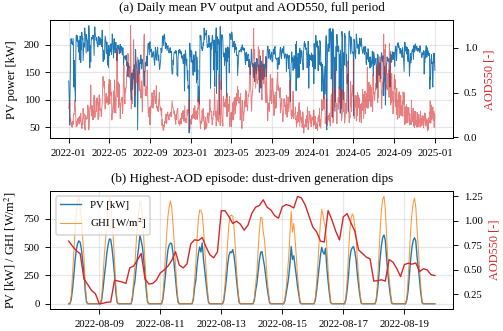

In [14]:
# Fig 1: PV output and irradiance over time, with a zoom on the dustiest episode
daily = df.resample("1D").agg({"pv_power_kw": "mean", "ghi": "mean", "aod550": "mean"})
dusty_end = daily["aod550"].rolling(5).mean().idxmax()
dusty_win = slice(dusty_end - pd.Timedelta(days=9), dusty_end + pd.Timedelta(days=3))

fig, axes = plt.subplots(2, 1, figsize=(TEXT_W_IN, 3.24))
ax = axes[0]
ax.plot(daily.index, daily["pv_power_kw"], lw=0.6, color="tab:blue", label="PV (daily mean, kW)")
ax2 = ax.twinx(); ax2.plot(daily.index, daily["aod550"], lw=0.6, color="tab:red", alpha=0.6, label="AOD550")
ax2.grid(False)
ax.set_ylabel("PV power [kW]"); ax2.set_ylabel("AOD550 [-]", color="tab:red")
ax.set_title("(a) Daily mean PV output and AOD550, full period")
ax = axes[1]
z = df.loc[dusty_win]
ax.plot(z.index, z["pv_power_kw"], lw=0.9, color="tab:blue", label="PV [kW]")
ax.plot(z.index, z["ghi"], lw=0.7, color="tab:orange", alpha=0.8, label="GHI [W/m$^2$]")
ax3 = ax.twinx(); ax3.plot(z.index, z["aod550"], lw=0.9, color="tab:red", label="AOD550"); ax3.grid(False)
ax3.set_ylabel("AOD550 [-]", color="tab:red")
ax.set_ylabel("PV [kW] / GHI [W/m$^2$]")
ax.set_title("(b) Highest-AOD episode: dust-driven generation dips")
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_eda_timeseries.png", bbox_inches="tight")
plt.show()

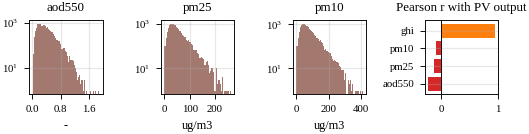

aod550   -0.232
pm25     -0.139
pm10     -0.105
ghi       0.944
dtype: float64


In [15]:
# Fig 2: aerosol distributions and correlation with PV output (daytime hours)
day = df[df["ghi"] > 10]
fig, axes = plt.subplots(1, 4, figsize=(TEXT_W_IN, 1.45))
for ax, col, unit in zip(axes[:3], ["aod550", "pm25", "pm10"], ["-", "ug/m3", "ug/m3"]):
    ax.hist(day[col], bins=60, color="tab:brown", alpha=0.8)
    ax.set_title(col); ax.set_xlabel(unit); ax.set_yscale("log")
    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
corr = day[["aod550", "pm25", "pm10", "ghi"]].corrwith(day["pv_power_kw"])
axes[3].barh(corr.index, corr.values, color=["tab:red"]*3 + ["tab:orange"])
axes[3].axvline(0, color="k", lw=0.6)
axes[3].set_title("Pearson r with PV output")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_aerosol_distributions.png", bbox_inches="tight")
plt.show()
print(corr.round(3))

## 4. Feature engineering (leakage-safe) and chronological split
Every feature is a lag of 24 h or more, or a deterministic calendar encoding, so a
forecast issued at 00:00 for the whole next day uses only information available at issue
time. Same-day weather and aerosol values are deliberately excluded: the target is a
deterministic pvlib function of same-hour irradiance, so including them would make the
task circular. Scaling is fit on the training rows only.

In [16]:
BASE_FEATURES = ["hour_sin", "hour_cos", "doy_sin", "doy_cos",
                 "pv_lag24", "pv_lag48", "pv_lag168",
                 "ghi_lag24", "dni_lag24", "dhi_lag24",
                 "temp_air_lag24", "wind_speed_lag24", "rh_lag24"]
AERO_FEATURES = ["aod550_lag24", "aod550_lag48", "pm25_lag24", "pm10_lag24"]
TARGET = "pv_power_kw"

def build_features(d):
    f = d.copy()
    f["hour_sin"] = np.sin(2*np.pi*f.index.hour/24);       f["hour_cos"] = np.cos(2*np.pi*f.index.hour/24)
    f["doy_sin"]  = np.sin(2*np.pi*f.index.dayofyear/365); f["doy_cos"]  = np.cos(2*np.pi*f.index.dayofyear/365)
    for lag in (24, 48, 168):
        f[f"pv_lag{lag}"] = f[TARGET].shift(lag)
    for c in ("ghi", "dni", "dhi", "temp_air", "wind_speed", "rh"):
        f[f"{c}_lag24"] = f[c].shift(24)
    for c in ("aod550", "pm25", "pm10"):
        f[f"{c}_lag24"] = f[c].shift(24)
    f["aod550_lag48"] = f["aod550"].shift(48)
    return f.dropna()

feat = build_features(df)

test_mask  = feat.index >= pd.Timestamp(TEST_START_DATE, tz="UTC")
train, test = feat[~test_mask], feat[test_mask]

TRAIN_START, TRAIN_END = train.index.min(), train.index.max()
TEST_START,  TEST_END  = test.index.min(),  test.index.max()
N_TRAIN, N_TEST = len(train), len(test)
print(f"TRAIN {TRAIN_START} -> {TRAIN_END}  ({N_TRAIN} rows)")
print(f"TEST  {TEST_START} -> {TEST_END}  ({N_TEST} rows)")

FEATS = {"aero": BASE_FEATURES + AERO_FEATURES, "noaero": BASE_FEATURES}
y_tr, y_te = train[TARGET].values, test[TARGET].values

TRAIN 2022-01-08 00:00:00+00:00 -> 2024-06-30 23:00:00+00:00  (21720 rows)
TEST  2024-07-01 00:00:00+00:00 -> 2024-12-31 21:00:00+00:00  (4414 rows)


In [17]:
# ------------------------------------------------------------------
# 5. Metrics: RMSE, MAE, R2, skill over persistence + day-block bootstrap CI
# ------------------------------------------------------------------
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def metrics(y, yhat, rmse_persist=None):
    rmse = float(np.sqrt(mean_squared_error(y, yhat)))
    out = {"RMSE": rmse, "MAE": mean_absolute_error(y, yhat), "R2": r2_score(y, yhat)}
    if rmse_persist is not None:
        out["SKILL"] = 100.0 * (1.0 - rmse / rmse_persist)   # [%] vs persistence
    return out

def block_bootstrap_rmse_ci(index, y, yhat, n_boot=1000, seed=SEED):
    # resample whole days to respect serial correlation
    days = pd.Series(index.date, index=index)
    uniq = days.unique(); rng = np.random.default_rng(seed)
    err = pd.Series((y - yhat) ** 2, index=index)
    by_day = err.groupby(days.values).mean().reindex(uniq)
    boots = [np.sqrt(by_day.iloc[rng.integers(0, len(uniq), len(uniq))].mean()) for _ in range(n_boot)]
    return np.percentile(boots, [2.5, 97.5])

## 5. Models
### 5.1 Smart persistence baseline
Same-hour-previous-day persistence: the forecast for hour *h* of day *d+1* is the observed
PV at hour *h* of day *d*. This preserves the diurnal shape and is the standard reference
for day-ahead skill scores (skill of persistence itself is 0 % by construction).

In [18]:
# Daytime evaluation mask: night hours (everything trivially ~0) would inflate R2
DAY_TE = (test["ghi"] > 10).values
print(f"daytime test hours: {DAY_TE.sum()} of {len(test)}")

pred = {}
pred["PERSIST"] = test["pv_lag24"].values
RMSE_PERSIST = metrics(y_te[DAY_TE], pred["PERSIST"][DAY_TE])["RMSE"]
res = {"PERSIST": metrics(y_te[DAY_TE], pred["PERSIST"][DAY_TE], RMSE_PERSIST)}
print(res["PERSIST"])

daytime test hours: 2165 of 4414
{'RMSE': 49.2090487713614, 'MAE': 30.718122794466403, 'R2': 0.9461372665930903, 'SKILL': 0.0}


In [19]:
# ------------------------------------------------------------------
# 5.2 CatBoost (gradient-boosted trees), with and without aerosols
# ------------------------------------------------------------------
from catboost import CatBoostRegressor

CAT_PARAMS = dict(depth=8, iterations=2000, learning_rate=0.05,
                  loss_function="RMSE", random_seed=SEED, verbose=0,
                  early_stopping_rounds=100)

# chronological validation tail (last 10% of train) for early stopping
val_cut = int(N_TRAIN * 0.9)
cat_models = {}
for key, cols in FEATS.items():
    m = CatBoostRegressor(**CAT_PARAMS)
    m.fit(train[cols].iloc[:val_cut], y_tr[:val_cut],
          eval_set=(train[cols].iloc[val_cut:], y_tr[val_cut:]))
    cat_models[key] = m
    name = "CAT_AERO" if key == "aero" else "CAT_NOAERO"
    pred[name] = np.clip(m.predict(test[cols]), 0, None)
    res[name] = metrics(y_te[DAY_TE], pred[name][DAY_TE], RMSE_PERSIST)
    print(name, {k: round(v, 3) for k, v in res[name].items()},
          "| best_iter:", m.get_best_iteration())

CAT_DEPTH, CAT_ITER_BEST, CAT_LR = 8, cat_models["aero"].get_best_iteration(), 0.05

CAT_AERO {'RMSE': 44.795, 'MAE': 28.801, 'R2': 0.955, 'SKILL': 8.97} | best_iter: 116
CAT_NOAERO {'RMSE': 45.392, 'MAE': 29.814, 'R2': 0.954, 'SKILL': 7.756} | best_iter: 213


In [20]:
# ------------------------------------------------------------------
# 5.3 Stacked GRU (2 GRU layers), with and without aerosols
# ------------------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Sequential, layers, callbacks, optimizers

GRU_LAYERS, GRU_UNITS, GRU_DROPOUT = 2, 64, 0.2
GRU_WINDOW, GRU_BATCH, GRU_MAX_EPOCHS, GRU_LR = 24, 256, 100, 1e-3

def make_sequences(X, y, window):
    # rows are already leakage-safe (lags >= 24 h), so a window of past rows is too
    Xs = np.stack([X[i-window+1:i+1] for i in range(window-1, len(X))])
    return Xs, y[window-1:], np.arange(window-1, len(X))

def build_gru(n_feat):
    tf.keras.utils.set_random_seed(SEED)
    m = Sequential([
        layers.Input((GRU_WINDOW, n_feat)),
        layers.GRU(GRU_UNITS, return_sequences=True),
        layers.Dropout(GRU_DROPOUT),
        layers.GRU(GRU_UNITS),
        layers.Dropout(GRU_DROPOUT),
        layers.Dense(1),
    ])
    m.compile(optimizer=optimizers.Adam(GRU_LR), loss="mse")
    return m

gru_epochs_run = {}
for key, cols in FEATS.items():
    xsc, ysc = StandardScaler().fit(train[cols]), StandardScaler().fit(y_tr.reshape(-1, 1))
    Xtr = xsc.transform(train[cols]); Xte = xsc.transform(test[cols])
    ytr_s = ysc.transform(y_tr.reshape(-1, 1)).ravel()

    Xtr_s, ytr_seq, _ = make_sequences(Xtr, ytr_s, GRU_WINDOW)
    # test sequences: prepend last (window-1) train rows so every test hour gets a prediction
    Xte_full = np.vstack([Xtr[-(GRU_WINDOW-1):], Xte])
    yte_pad  = np.concatenate([np.zeros(GRU_WINDOW-1), y_te])
    Xte_s, _, keep = make_sequences(Xte_full, yte_pad, GRU_WINDOW)

    n_val = int(len(Xtr_s) * 0.1)   # chronological tail as validation
    m = build_gru(len(cols))
    h = m.fit(Xtr_s[:-n_val], ytr_seq[:-n_val],
              validation_data=(Xtr_s[-n_val:], ytr_seq[-n_val:]),
              epochs=GRU_MAX_EPOCHS, batch_size=GRU_BATCH, verbose=0,
              callbacks=[callbacks.EarlyStopping(patience=10, restore_best_weights=True)])
    gru_epochs_run[key] = len(h.history["loss"])
    yhat = ysc.inverse_transform(m.predict(Xte_s, verbose=0)).ravel()
    name = "GRU_AERO" if key == "aero" else "GRU_NOAERO"
    pred[name] = np.clip(yhat, 0, None)
    res[name] = metrics(y_te[DAY_TE], pred[name][DAY_TE], RMSE_PERSIST)
    print(name, {k: round(v, 3) for k, v in res[name].items()},
          "| epochs:", gru_epochs_run[key])

GRU_EPOCHS = gru_epochs_run["aero"]

I0000 00:00:1788610009.213623      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


GRU_AERO {'RMSE': 45.481, 'MAE': 29.536, 'R2': 0.954, 'SKILL': 7.575} | epochs: 28
GRU_NOAERO {'RMSE': 48.472, 'MAE': 34.425, 'R2': 0.948, 'SKILL': 1.498} | epochs: 32


## 6. Results: main table, ablation deltas, dust-day breakdown

In [21]:
main_table = pd.DataFrame(res).T[["RMSE", "MAE", "R2", "SKILL"]].round(3)
main_table.to_csv("results_main.csv")
print(main_table)

SKILL_GAIN_CAT_PCT = res["CAT_AERO"]["SKILL"] - res["CAT_NOAERO"]["SKILL"]
SKILL_GAIN_GRU_PCT = res["GRU_AERO"]["SKILL"] - res["GRU_NOAERO"]["SKILL"]
print(f"\nAblation deltas (percentage points of skill): "
      f"CatBoost {SKILL_GAIN_CAT_PCT:+.2f} | GRU {SKILL_GAIN_GRU_PCT:+.2f}")

              RMSE     MAE     R2  SKILL
PERSIST     49.209  30.718  0.946  0.000
CAT_AERO    44.795  28.801  0.955  8.970
CAT_NOAERO  45.392  29.814  0.954  7.756
GRU_AERO    45.481  29.536  0.954  7.575
GRU_NOAERO  48.472  34.425  0.948  1.498

Ablation deltas (percentage points of skill): CatBoost +1.21 | GRU +6.08


In [22]:
# High-dust vs low-dust breakdown (threshold = train-set AOD percentile, daytime hours)
AOD_THRESHOLD = np.percentile(train["aod550"], DUST_PCTL)
hi = (test["aod550"] >= AOD_THRESHOLD) & (test["ghi"] > 10)
lo = (test["aod550"] <  AOD_THRESHOLD) & (test["ghi"] > 10)
print(f"AOD threshold (p{DUST_PCTL} of train) = {AOD_THRESHOLD:.3f} | "
      f"high-dust hours: {hi.sum()} | low-dust hours: {lo.sum()}")

res_dust = {}
for sub, mask in [("HIDUST", hi.values), ("LODUST", lo.values)]:
    rp = metrics(y_te[mask], pred["PERSIST"][mask])["RMSE"]
    for name in ["PERSIST", "CAT_NOAERO", "CAT_AERO", "GRU_NOAERO", "GRU_AERO"]:
        res_dust[f"{name}_{sub}"] = metrics(y_te[mask], pred[name][mask], rp)

dust_table = pd.DataFrame(res_dust).T[["RMSE", "MAE", "R2", "SKILL"]].round(3)
dust_table.to_csv("results_dust.csv")
print(dust_table)

SKILL_GAIN_GRU_HIDUST_PCT = res_dust["GRU_AERO_HIDUST"]["SKILL"] - res_dust["GRU_NOAERO_HIDUST"]["SKILL"]
SKILL_GAIN_GRU_LODUST_PCT = res_dust["GRU_AERO_LODUST"]["SKILL"] - res_dust["GRU_NOAERO_LODUST"]["SKILL"]
SKILL_GAIN_CAT_HIDUST_PCT = res_dust["CAT_AERO_HIDUST"]["SKILL"] - res_dust["CAT_NOAERO_HIDUST"]["SKILL"]
SKILL_GAIN_CAT_LODUST_PCT = res_dust["CAT_AERO_LODUST"]["SKILL"] - res_dust["CAT_NOAERO_LODUST"]["SKILL"]
print(f"\nAerosol skill gain, high vs low dust: "
      f"GRU {SKILL_GAIN_GRU_HIDUST_PCT:+.2f} / {SKILL_GAIN_GRU_LODUST_PCT:+.2f} pp | "
      f"CatBoost {SKILL_GAIN_CAT_HIDUST_PCT:+.2f} / {SKILL_GAIN_CAT_LODUST_PCT:+.2f} pp")

AOD threshold (p75 of train) = 0.478 | high-dust hours: 698 | low-dust hours: 1467
                     RMSE     MAE     R2  SKILL
PERSIST_HIDUST     57.030  36.388  0.908  0.000
CAT_NOAERO_HIDUST  52.238  33.219  0.923  8.402
CAT_AERO_HIDUST    51.895  32.837  0.924  9.005
GRU_NOAERO_HIDUST  51.767  34.763  0.924  9.228
GRU_AERO_HIDUST    52.841  34.644  0.921  7.346
PERSIST_LODUST     45.013  28.021  0.956  0.000
CAT_NOAERO_LODUST  41.742  28.195  0.963  7.266
CAT_AERO_LODUST    40.987  26.881  0.964  8.944
GRU_NOAERO_LODUST  46.822  34.264  0.953 -4.019
GRU_AERO_LODUST    41.524  27.105  0.963  7.751

Aerosol skill gain, high vs low dust: GRU -1.88 / +11.77 pp | CatBoost +0.60 / +1.68 pp


In [23]:
# Bootstrap 95% CIs on test RMSE (day blocks)
ci = {name: block_bootstrap_rmse_ci(test.index[DAY_TE], y_te[DAY_TE], pred[name][DAY_TE])
      for name in ["PERSIST", "CAT_AERO", "CAT_NOAERO", "GRU_AERO", "GRU_NOAERO"]}
for k, v in ci.items():
    print(f"RMSE_{k}: {res[k]['RMSE']:.2f} kW  [95% CI {v[0]:.2f}, {v[1]:.2f}]")

RMSE_PERSIST: 49.21 kW  [95% CI 43.61, 54.58]
RMSE_CAT_AERO: 44.79 kW  [95% CI 39.54, 50.00]
RMSE_CAT_NOAERO: 45.39 kW  [95% CI 40.31, 50.33]
RMSE_GRU_AERO: 45.48 kW  [95% CI 39.99, 51.22]
RMSE_GRU_NOAERO: 48.47 kW  [95% CI 43.88, 53.02]


### 6b. Paired bootstrap and release export (camera-ready)


In [ ]:
# ------------------------------------------------------------------
# 6b. Paired day-block bootstrap of the aerosol effect (camera-ready, reviewer request)
# Both variants of a model family are scored on the SAME resampled days, so the
# day-to-day difficulty they share cancels. Same day-block convention as
# block_bootstrap_rmse_ci above (resample whole days, RMSE = sqrt(mean of daily MSE)).
# ------------------------------------------------------------------
def paired_block_bootstrap(index, y, yhat_base, yhat_aero, n_boot=1000, seed=SEED):
    days = pd.Series(index.date, index=index)
    uniq = days.unique(); rng = np.random.default_rng(seed)
    mse_b = pd.Series((y - yhat_base) ** 2, index=index).groupby(days.values).mean().reindex(uniq)
    mse_a = pd.Series((y - yhat_aero) ** 2, index=index).groupby(days.values).mean().reindex(uniq)
    deltas = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(uniq), len(uniq))
        deltas.append(np.sqrt(mse_b.iloc[idx].mean()) - np.sqrt(mse_a.iloc[idx].mean()))
    deltas = np.array(deltas)
    point = np.sqrt(np.mean((y - yhat_base) ** 2)) - np.sqrt(np.mean((y - yhat_aero) ** 2))
    lo_ci, hi_ci = np.percentile(deltas, [2.5, 97.5])
    return point, lo_ci, hi_ci, float(np.mean(deltas <= 0))

masks = {"all daytime": DAY_TE, "high dust": hi.values, "low dust": lo.values}
pairs = {"CatBoost": ("CAT_NOAERO", "CAT_AERO"), "Stacked GRU": ("GRU_NOAERO", "GRU_AERO")}
paired_rows = []
for model, (b, a) in pairs.items():
    for sub, m in masks.items():
        pt, l, h, p = paired_block_bootstrap(test.index[m], y_te[m], pred[b][m], pred[a][m])
        paired_rows.append((model, sub, pt, l, h, p))
        print(f"{model:12s} {sub:12s} dRMSE={pt:+.2f} kW  95% CI [{l:.2f}, {h:.2f}]  p(d<=0)={p:.3f}")

print("\nLaTeX rows for Table 3 (paste into main.tex):")
for model, sub, pt, l, h, p in paired_rows:
    ptxt = f"{pt:.2f}" if pt >= 0 else f"$-{abs(pt):.2f}$"
    print(f"    {model} & {sub} & {ptxt} & [{l:.2f}, {h:.2f}] & {p:.3f} \\\\")


In [ ]:
# ------------------------------------------------------------------
# 6c. Export for the public GitHub release
# ------------------------------------------------------------------
REL = pathlib.Path("release"); REL.mkdir(exist_ok=True)
df.to_csv(REL / "oman_desert_pv_dataset.csv")                 # merged hourly dataset
out = pd.DataFrame({"y_true": y_te, "ghi": test["ghi"].values, "aod550": test["aod550"].values,
                    "daytime": DAY_TE, "high_dust": hi.values,
                    "persistence": pred["PERSIST"],
                    "cat_base": pred["CAT_NOAERO"], "cat_aero": pred["CAT_AERO"],
                    "gru_base": pred["GRU_NOAERO"], "gru_aero": pred["GRU_AERO"]},
                   index=test.index.rename("timestamp_utc"))
out.to_csv(REL / "test_predictions.csv")
main_table.to_csv(REL / "results_main.csv"); dust_table.to_csv(REL / "results_dust.csv")
pd.DataFrame(paired_rows, columns=["model", "subset", "dRMSE_kW", "ci_lo", "ci_hi", "p_le0"]) \
  .to_csv(REL / "results_paired_bootstrap.csv", index=False)
print("Wrote:", sorted(p.name for p in REL.iterdir()))


## 7. Comparison and diagnostic figures (paper Figs. 4-7)

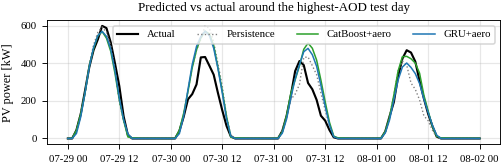

In [24]:
# Fig (paper Fig. 4): short horizon, predicted vs actual over a representative window
# that includes the highest-AOD test day plus its neighbours
hi_day = test.loc[hi.values, "aod550"].resample("1D").mean().idxmax()
win = slice(hi_day - pd.Timedelta(days=2), hi_day + pd.Timedelta(days=2))
tw = test.loc[win]; iw = test.index.get_indexer(tw.index)

fig, ax = plt.subplots(figsize=(TEXT_W_IN, 1.74))
ax.plot(tw.index, y_te[iw], "k-", lw=1.4, label="Actual")
ax.plot(tw.index, pred["PERSIST"][iw], color="gray", lw=0.9, ls=":", label="Persistence")
ax.plot(tw.index, pred["CAT_AERO"][iw], color="tab:green", lw=1.0, label="CatBoost+aero")
ax.plot(tw.index, pred["GRU_AERO"][iw], color="tab:blue", lw=1.0, label="GRU+aero")
ax.set_ylabel("PV power [kW]"); ax.legend(ncol=4)
ax.set_title("Predicted vs actual around the highest-AOD test day")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig5_short_horizon.png", bbox_inches="tight")
plt.show()

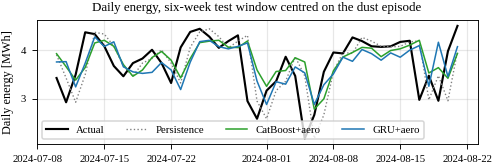

In [25]:
# Fig (paper Fig. 5): longer horizon, daily energy over six test weeks
dtest = pd.DataFrame({"actual": y_te, "PERSIST": pred["PERSIST"],
                      "CAT_AERO": pred["CAT_AERO"], "GRU_AERO": pred["GRU_AERO"]},
                     index=test.index)
denergy = (dtest.resample("1D").sum() / 1000.0)   # kWh -> MWh per day
w6 = denergy.loc[hi_day - pd.Timedelta(days=21): hi_day + pd.Timedelta(days=21)]

fig, ax = plt.subplots(figsize=(TEXT_W_IN, 1.74))
ax.plot(w6.index, w6["actual"], "k-", lw=1.4, label="Actual")
ax.plot(w6.index, w6["PERSIST"], color="gray", ls=":", lw=0.9, label="Persistence")
ax.plot(w6.index, w6["CAT_AERO"], color="tab:green", lw=1.0, label="CatBoost+aero")
ax.plot(w6.index, w6["GRU_AERO"], color="tab:blue", lw=1.0, label="GRU+aero")
ax.set_ylabel("Daily energy [MWh]"); ax.legend(ncol=4)
ax.set_title("Daily energy, six-week test window centred on the dust episode")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig6_long_horizon.png", bbox_inches="tight")
plt.show()

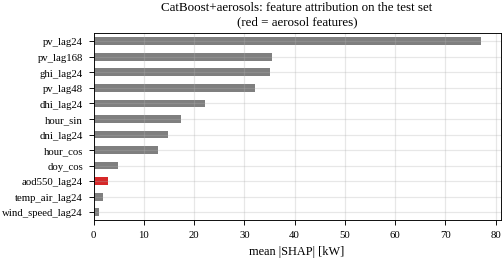

pv_lag24     77.16
pv_lag168    35.52
ghi_lag24    35.01
pv_lag48     32.03
dhi_lag24    22.26
dtype: float64


In [26]:
# ------------------------------------------------------------------
# 8. SHAP attribution on CatBoost-with-aerosols (TreeExplainer, native)
# Attribution is CatBoost-based; no DeepExplainer is attempted on the GRU.
# ------------------------------------------------------------------
explainer = shap.TreeExplainer(cat_models["aero"])
Xte_aero = test[FEATS["aero"]][DAY_TE]   # attribute on daytime hours
shap_vals = explainer.shap_values(Xte_aero)

mean_abs = pd.Series(np.abs(shap_vals).mean(axis=0), index=FEATS["aero"]).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(TEXT_W_IN, 2.60))
mean_abs.head(12)[::-1].plot.barh(ax=ax, color=["tab:red" if f in AERO_FEATURES else "tab:gray"
                                                for f in mean_abs.head(12)[::-1].index])
ax.set_xlabel("mean |SHAP| [kW]")
ax.set_title("CatBoost+aerosols: feature attribution on the test set\n(red = aerosol features)")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig7_shap.png", bbox_inches="tight")
plt.show()
SHAP_TOP5 = mean_abs.head(5)
print(SHAP_TOP5.round(2))

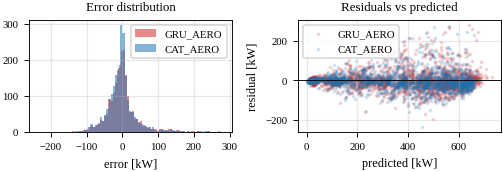

In [27]:
# Fig (paper Fig. 7): residual diagnostics for the two best variants
fig, axes = plt.subplots(1, 2, figsize=(TEXT_W_IN, 1.80))
for name, color in [("GRU_AERO", "tab:red"), ("CAT_AERO", "tab:blue")]:
    e = pred[name][DAY_TE] - y_te[DAY_TE]
    axes[0].hist(e, bins=80, alpha=0.55, label=name, color=color)
    axes[1].scatter(pred[name][DAY_TE], e, s=2, alpha=0.15, color=color, label=name)
axes[0].set_xlabel("error [kW]"); axes[0].set_title("Error distribution"); axes[0].legend()
axes[1].axhline(0, color="k", lw=0.6)
axes[1].set_xlabel("predicted [kW]"); axes[1].set_ylabel("residual [kW]")
axes[1].set_title("Residuals vs predicted"); axes[1].legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "fig8_residuals.png", bbox_inches="tight")
plt.show()

## 9. Results summary block
One value per line. Each label matches a `[[LABEL]]` blank in the companion paper:
copy the value straight into the corresponding blank.

In [28]:
def emit(label, value):
    print(f"[[{label}]] = {value}")

print("=" * 64); print("RESULTS SUMMARY BLOCK"); print("=" * 64)

# --- dataset ---
emit("SITE_LAT", SITE_LAT); emit("SITE_LON", SITE_LON)
emit("TRAIN_START", TRAIN_START.strftime("%Y-%m-%d %H:%M"))
emit("TRAIN_END",   TRAIN_END.strftime("%Y-%m-%d %H:%M"))
emit("TEST_START",  TEST_START.strftime("%Y-%m-%d %H:%M"))
emit("TEST_END",    TEST_END.strftime("%Y-%m-%d %H:%M"))
emit("N_ROWS", N_ROWS); emit("N_TRAIN", N_TRAIN); emit("N_TEST", N_TEST)
emit("AOD_THRESHOLD", round(float(AOD_THRESHOLD), 3))
emit("N_HIDUST", int(hi.sum())); emit("N_LODUST", int(lo.sum()))

# --- main metrics (RMSE/MAE in kW, R2 dimensionless, SKILL in %) ---
for name in ["PERSIST", "CAT_NOAERO", "CAT_AERO", "GRU_NOAERO", "GRU_AERO"]:
    emit(f"RMSE_{name}",  round(res[name]["RMSE"], 2))
    emit(f"MAE_{name}",   round(res[name]["MAE"], 2))
    emit(f"R2_{name}",    round(res[name]["R2"], 3))
    emit(f"SKILL_{name}", round(res[name].get("SKILL", 0.0), 2))

# --- bootstrap CIs on RMSE ---
for name in ["PERSIST", "CAT_NOAERO", "CAT_AERO", "GRU_NOAERO", "GRU_AERO"]:
    emit(f"RMSE_{name}_CI_LO", round(ci[name][0], 2))
    emit(f"RMSE_{name}_CI_HI", round(ci[name][1], 2))

# --- ablation deltas (percentage points) ---
emit("SKILL_GAIN_CAT_PCT", round(SKILL_GAIN_CAT_PCT, 2))
emit("SKILL_GAIN_GRU_PCT", round(SKILL_GAIN_GRU_PCT, 2))

# --- high vs low dust ---
for key, r in res_dust.items():
    emit(f"RMSE_{key}",  round(r["RMSE"], 2))
    emit(f"MAE_{key}",   round(r["MAE"], 2))
    emit(f"R2_{key}",    round(r["R2"], 3))
    emit(f"SKILL_{key}", round(r.get("SKILL", 0.0), 2))
emit("SKILL_GAIN_GRU_HIDUST_PCT", round(SKILL_GAIN_GRU_HIDUST_PCT, 2))
emit("SKILL_GAIN_GRU_LODUST_PCT", round(SKILL_GAIN_GRU_LODUST_PCT, 2))
emit("SKILL_GAIN_CAT_HIDUST_PCT", round(SKILL_GAIN_CAT_HIDUST_PCT, 2))
emit("SKILL_GAIN_CAT_LODUST_PCT", round(SKILL_GAIN_CAT_LODUST_PCT, 2))

# --- SHAP top-5 (mean |SHAP|, kW) ---
for i, (feat_name, val) in enumerate(SHAP_TOP5.items(), 1):
    emit(f"SHAP_TOP{i}", f"{feat_name} ({val:.2f})")

# --- model hyperparameters ---
emit("GRU_LAYERS", GRU_LAYERS); emit("GRU_UNITS", GRU_UNITS); emit("GRU_EPOCHS", GRU_EPOCHS)
emit("GRU_DROPOUT", GRU_DROPOUT); emit("GRU_WINDOW", GRU_WINDOW); emit("GRU_BATCH", GRU_BATCH)
emit("CAT_DEPTH", CAT_DEPTH); emit("CAT_ITERATIONS", CAT_ITER_BEST); emit("CAT_LR", CAT_LR)
print("=" * 64)
print("Figures exported to ./figures at", FIG_DPI, "DPI:",
      sorted(p.name for p in FIG_DIR.glob("*.png")))

RESULTS SUMMARY BLOCK
[[SITE_LAT]] = 23.05
[[SITE_LON]] = 56.42
[[TRAIN_START]] = 2022-01-08 00:00
[[TRAIN_END]] = 2024-06-30 23:00
[[TEST_START]] = 2024-07-01 00:00
[[TEST_END]] = 2024-12-31 21:00
[[N_ROWS]] = 26302
[[N_TRAIN]] = 21720
[[N_TEST]] = 4414
[[AOD_THRESHOLD]] = 0.478
[[N_HIDUST]] = 698
[[N_LODUST]] = 1467
[[RMSE_PERSIST]] = 49.21
[[MAE_PERSIST]] = 30.72
[[R2_PERSIST]] = 0.946
[[SKILL_PERSIST]] = 0.0
[[RMSE_CAT_NOAERO]] = 45.39
[[MAE_CAT_NOAERO]] = 29.81
[[R2_CAT_NOAERO]] = 0.954
[[SKILL_CAT_NOAERO]] = 7.76
[[RMSE_CAT_AERO]] = 44.79
[[MAE_CAT_AERO]] = 28.8
[[R2_CAT_AERO]] = 0.955
[[SKILL_CAT_AERO]] = 8.97
[[RMSE_GRU_NOAERO]] = 48.47
[[MAE_GRU_NOAERO]] = 34.42
[[R2_GRU_NOAERO]] = 0.948
[[SKILL_GRU_NOAERO]] = 1.5
[[RMSE_GRU_AERO]] = 45.48
[[MAE_GRU_AERO]] = 29.54
[[R2_GRU_AERO]] = 0.954
[[SKILL_GRU_AERO]] = 7.58
[[RMSE_PERSIST_CI_LO]] = 43.61
[[RMSE_PERSIST_CI_HI]] = 54.58
[[RMSE_CAT_NOAERO_CI_LO]] = 40.31
[[RMSE_CAT_NOAERO_CI_HI]] = 50.33
[[RMSE_CAT_AERO_CI_LO]] = 39.54
[[RM